In [1]:
%cd /content
!rm -rf mccain-internship
!git clone https://github.com/PushkargithubCSE/mccain-internship.git
%cd mccain-internship/week-3/potato-finetuning
!pwd

/content
Cloning into 'mccain-internship'...
remote: Enumerating objects: 587, done.
remote: Counting objects: 100% (587/587), done.
remote: Compressing objects: 100% (431/431), done.
remote: Total 587 (delta 154), reused 524 (delta 97), pack-reused 0 (from 0)
Receiving objects: 100% (587/587), 26.06 MiB | 33.83 MiB/s, done.
Resolving deltas: 100% (154/154), done.
/content/mccain-internship/week-3/potato-finetuning
/content/mccain-internship/week-3/potato-finetuning


In [6]:
!nvidia-smi

Tue Sep 15 21:46:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.86                 Driver Version: 581.86         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   38C    P3              8W /   35W |       0MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
!pip install torch==2.12.0 torchvision==0.27.0 --index-url https://download.pytorch.org/whl/cu130

Looking in indexes: https://download.pytorch.org/whl/cu130
  Using cached filelock-3.32.3-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached numpy-2.5.2-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/1.9 GB ? eta -:--:--
   ---------------------------------------- 0.0/1.9 GB 7.5 MB/s eta 0:04:18
   ---------------------------------------- 0.0/1.9 GB 5.4 MB/s eta 0:05:57
   ---------------------------------------- 0.0/1.9 GB 3.9 MB/s eta 0:08:16
   ---------------------------------------- 0.0/1.9 GB 3.1 MB/s eta 0:10:14
   -------------------------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
!pip install -q "rfdetr[train,metrics,loggers]"
!pip install -q roboflow python-dotenv


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [ ]:
PROJECT_PATH = "C:\\Users\\Pushkar Chandra\\mccain-internship\\week-3\\potato-finetuning"

roboflow_key = "YOUR_API_KEY_HERE"  
hf_token_value = "YOUR_HUGGINGFACE_TOKEN_HERE"

with open(f"{PROJECT_PATH}/.env", "w") as f:
    f.write(f"ROBOFLOW_API_KEY={roboflow_key}\n")
    f.write(f"HUGGINGFACE_TOKEN={hf_token_value}\n")

print("✓ .env created with both keys")

✓ .env created with both keys


In [12]:
import os
from dotenv import load_dotenv

PROJECT_PATH = "C:\\Users\\Pushkar Chandra\\mccain-internship\\week-3\\potato-finetuning"
load_dotenv(f"{PROJECT_PATH}/.env")

api_key = os.getenv("ROBOFLOW_API_KEY")
if not api_key:
    raise RuntimeError("ROBOFLOW_API_KEY is missing from the project .env file")

In [ ]:
import os
from dotenv import load_dotenv
from roboflow import Roboflow

load_dotenv(f"{PROJECT_PATH}/.env")
api_key = os.getenv('ROBOFLOW_API_KEY')

rf = Roboflow(api_key=api_key)
project = rf.workspace("pushkar-chandra").project("new-hyjg2-q4cv4")
version = project.version(2)
dataset = version.download("coco")
                


print(f"✓ Dataset ready at: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to new-2 in coco:: 100%|██████████| 1683/1683 [00:01<00:00, 1304.53it/s]

✓ Dataset ready at: c:\Users\Pushkar Chandra\mccain-internship\week-3\potato-finetuning\notebooks - rfdetr\new-2


In [14]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [15]:
!pip install -q huggingface_hub


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from huggingface_hub import login
import os
from dotenv import load_dotenv

PROJECT_PATH = "/content/mccain-internship/week-3/potato-finetuning"
load_dotenv(f"{PROJECT_PATH}/.env")

hf_token = os.getenv("HUGGINGFACE_TOKEN")
print("Token loaded from .env:", bool(hf_token))

login(token=hf_token)  # explicit token, bypasses any secrets vault lookup
print("✓ Logged into Hugging Face")

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Token loaded from .env: False


✓ Logged into Hugging Face


In [8]:
!pip install -q pyngrok

In [9]:
import os
from dotenv import load_dotenv
from pyngrok import ngrok
import subprocess
import time

PROJECT_PATH = "/content/mccain-internship/week-3/potato-finetuning"
OUTPUT_DIR = f"{PROJECT_PATH}/checkpoints/rfdetr_run1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

load_dotenv(f"{PROJECT_PATH}/.env")
ngrok_token = os.getenv("NGROK_AUTHTOKEN")
if not ngrok_token:
    raise RuntimeError("NGROK_AUTHTOKEN is missing from the project .env file")
ngrok.set_auth_token(ngrok_token)

!pkill -f tensorboard
ngrok.kill()

subprocess.Popen(['tensorboard', '--logdir', OUTPUT_DIR, '--host', '0.0.0.0', '--port', '6006'])
time.sleep(4)

✓ Open this in your browser NOW (will populate once training starts): NgrokTunnel: "https://erin-cataclysmic-tegularly.ngrok-free.dev" -> "http://localhost:6006"


In [17]:
from rfdetr import RFDETRBase
from dotenv import load_dotenv
from huggingface_hub import login, HfApi, create_repo
import os

PROJECT_PATH = "C:\\Users\\Pushkar Chandra\\mccain-internship\\week-3\\potato-finetuning"
OUTPUT_DIR = f"{PROJECT_PATH}/checkpoints/rfdetr_run1"

# --- TRAIN ---
model = RFDETRBase()

model.train(
    dataset_dir=dataset.location,
    epochs=30,
    batch_size=2,
    grad_accum_steps=8,
    lr=1e-4,
    output_dir=OUTPUT_DIR,
    early_stopping=True
)
print("Training complete.")

# --- UPLOAD IMMEDIATELY, SAME CELL ---
load_dotenv(f"{PROJECT_PATH}/.env")
hf_token = os.getenv("HUGGINGFACE_TOKEN")
if not hf_token:
    raise RuntimeError("HUGGINGFACE_TOKEN is missing from the project .env file")
login(token=hf_token)

REPO_ID = "pushkar0002/finetune"

api = HfApi()
create_repo(repo_id=REPO_ID, exist_ok=True, repo_type="model")
api.upload_folder(folder_path=OUTPUT_DIR, repo_id=REPO_ID, repo_type="model")

print(f"Checkpoint safely uploaded to: https://huggingface.co/{REPO_ID}")

Val (ema) (Epoch 30/30) — Overall Metrics            
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃           mAP            ┃  mAR   ┃         F1 sweep         ┃
┡━━━━━━━━┯━━━━━━━━┯━━━━━━━━╇━━━━━━━━╇━━━━━━━━┯━━━━━━━━┯━━━━━━━━┩
│ 50:95  │   50   │   75   │  @500  │   F1   │  Prec  │ Recall │
├────────┼────────┼────────┼────────┼────────┼────────┼────────┤
│ 0.6069 │ 0.7888 │ 0.6342 │ 0.8225 │ 0.7644 │ 0.7705 │ 0.7702 │
└────────┴────────┴────────┴────────┴────────┴────────┴────────┘

`Trainer.fit` stopped: `max_epochs=30` reached.


[2026-09-16 00:46:51] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.0000, ema=0.6073)
Training complete.


HfHubHTTPError: Invalid user token.

In [21]:
from dotenv import load_dotenv
import os

PROJECT_PATH = r"C:\Users\Pushkar Chandra\mccain-internship\week-3\potato-finetuning"

load_dotenv(f"{PROJECT_PATH}/.env", override=True)

hf_token = os.getenv("HUGGINGFACE_TOKEN")

print("Token found:", hf_token is not None)
print("Token starts with:", hf_token[:7] if hf_token else None)
print("Token length:", len(hf_token) if hf_token else 0)

Token found: True
Token starts with: hf_wdEB
Token length: 37


In [22]:
load_dotenv(f"{PROJECT_PATH}/.env") 
hf_token = os.getenv("HUGGINGFACE_TOKEN") 
if not hf_token: 
    raise RuntimeError("HUGGINGFACE_TOKEN is missing from the project .env file") 
login(token=hf_token) 
 
REPO_ID = "pushkar0002/finetune" 
 
api = HfApi() 
create_repo(repo_id=REPO_ID, exist_ok=True, repo_type="model") 
api.upload_folder(folder_path=OUTPUT_DIR, repo_id=REPO_ID, repo_type="model") 
 
print(f"Checkpoint safely uploaded to: https://huggingface.co/{REPO_ID}")


Checkpoint safely uploaded to: https://huggingface.co/pushkar0002/finetune


In [24]:
import os

PROJECT_PATH = "C:\\Users\\Pushkar Chandra\\mccain-internship\\week-3\\potato-finetuning"

print("PROJECT_PATH exists:", os.path.exists(PROJECT_PATH))

checkpoints_dir = f"{PROJECT_PATH}/checkpoints"
print("checkpoints/ exists:", os.path.exists(checkpoints_dir))

if os.path.exists(checkpoints_dir):
    print("Contents of checkpoints/:", os.listdir(checkpoints_dir))
else:
    print("checkpoints/ folder doesn't exist at all")

PROJECT_PATH exists: True
checkpoints/ exists: True
Contents of checkpoints/: ['full_finetune', 'linear_probe', 'lora', 'rfdetr_run1']


In [25]:
import os

PROJECT_PATH = "C:\\Users\\Pushkar Chandra\\mccain-internship\\week-3\\potato-finetuning"
OUTPUT_DIR = f"{PROJECT_PATH}/checkpoints/rfdetr_run1"

print("Exists:", os.path.exists(OUTPUT_DIR))
if os.path.exists(OUTPUT_DIR):
    print("Files:", os.listdir(OUTPUT_DIR))

Exists: True
Files: ['checkpoint_19.ckpt', 'checkpoint_29.ckpt', 'checkpoint_9.ckpt', 'checkpoint_best_ema.pth', 'checkpoint_best_total.pth', 'events.out.tfevents.1789494024.LAPTOP-135LIQGM.26060.0', 'hparams.yaml', 'last.ckpt', 'last_ema.pth', 'metrics.csv', 'training_config.json']


In [ ]:
!du -sh {OUTPUT_DIR}

Loading checkpoint:
C:\Users\Pushkar Chandra\mccain-internship\week-3\potato-finetuning\checkpoints\rfdetr_run1\checkpoint_best_total.pth


[2026-09-16 01:25:51] [WARNING] rf-detr - Checkpoint has 6 classes but model is configured for 90. Using checkpoint class count (6). Pass num_classes=6 to suppress this warning.


Fine-tuned model loaded successfully!

Found 6 test images:
 - 56225459-c976-486b-ab4b-a826b5d9e3f3.png
 - 5949ee01-1657-4224-a6c5-d08040817b7a.png
 - case-1000001223.jpg
 - image.png
 - Screenshot 2026-09-07 163209.png
 - Screenshot 2026-09-07 163236.png


[2026-09-16 01:25:52] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).



IMAGE: 56225459-c976-486b-ab4b-a826b5d9e3f3.png
DETECTIONS: 3
1. midum (confidence=0.823) box=[17, 177, 1232, 1041]
2. defect (confidence=0.633) box=[1051, 618, 1206, 759]
3. defect (confidence=0.515) box=[127, 260, 419, 1021]


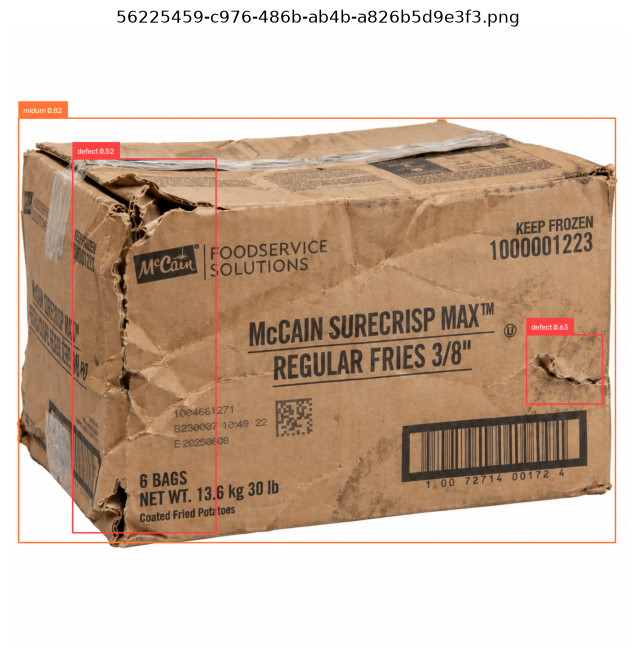


IMAGE: 5949ee01-1657-4224-a6c5-d08040817b7a.png
DETECTIONS: 2
1. midum (confidence=0.873) box=[20, 172, 1240, 1070]
2. defect (confidence=0.723) box=[59, 223, 556, 1020]


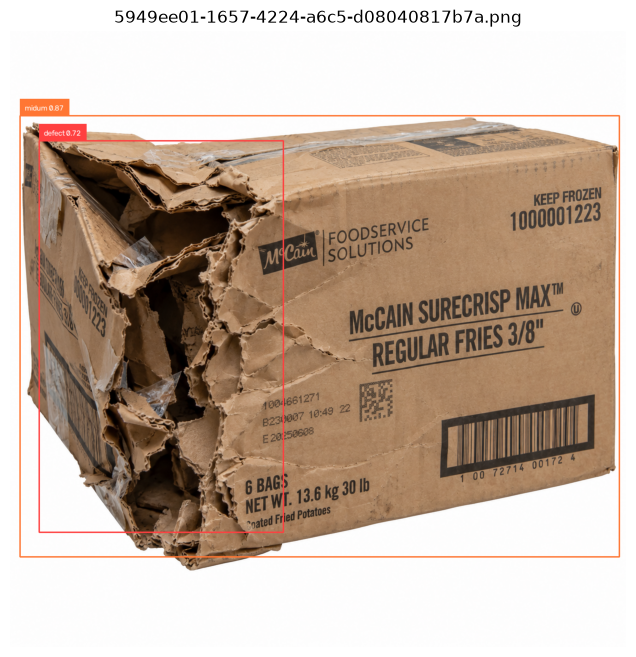


IMAGE: case-1000001223.jpg
DETECTIONS: 2
1. normal (confidence=0.969) box=[10, 93, 486, 407]
2. midum (confidence=0.889) box=[9, 92, 487, 407]


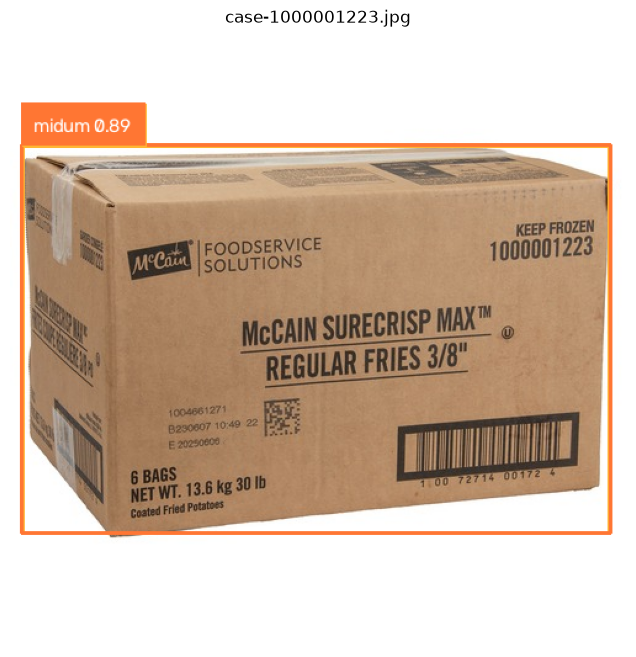


IMAGE: image.png
DETECTIONS: 2
1. midum (confidence=0.913) box=[78, 83, 422, 289]
2. defect (confidence=0.748) box=[185, 144, 362, 269]


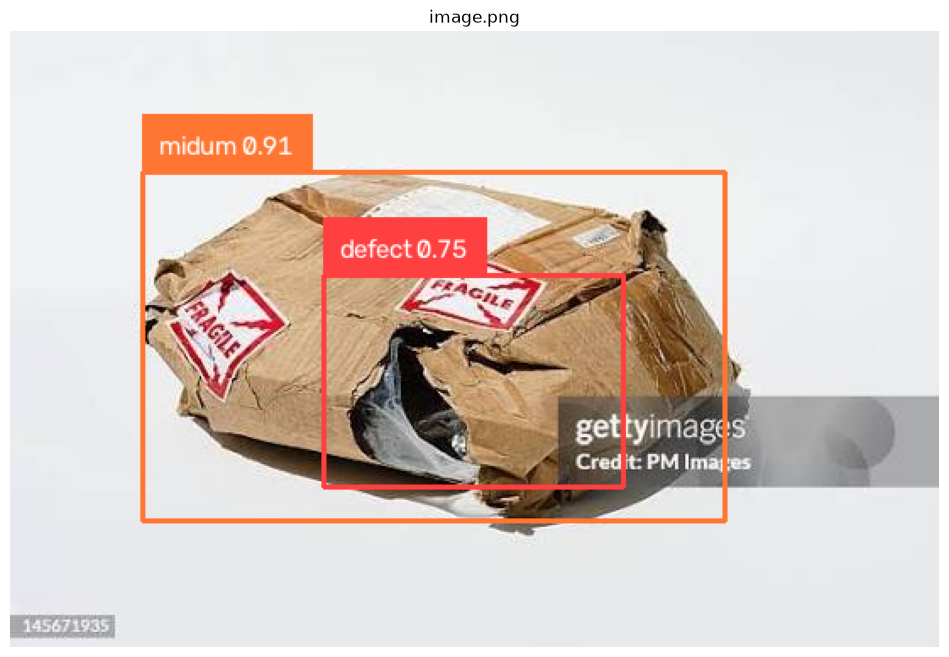


IMAGE: Screenshot 2026-09-07 163209.png
DETECTIONS: 4
1. midum (confidence=0.844) box=[341, 260, 533, 465]
2. midum (confidence=0.779) box=[148, 288, 366, 484]
3. normal (confidence=0.743) box=[149, 289, 365, 483]
4. midum (confidence=0.550) box=[176, 137, 419, 290]


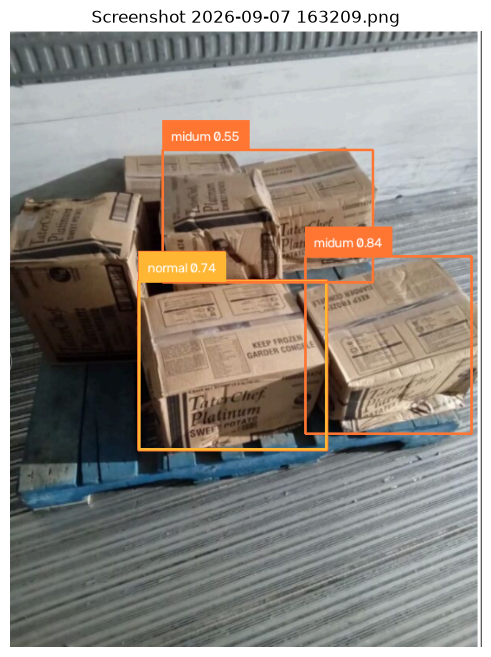


IMAGE: Screenshot 2026-09-07 163236.png
DETECTIONS: 1
1. midum (confidence=0.542) box=[51, 82, 280, 273]


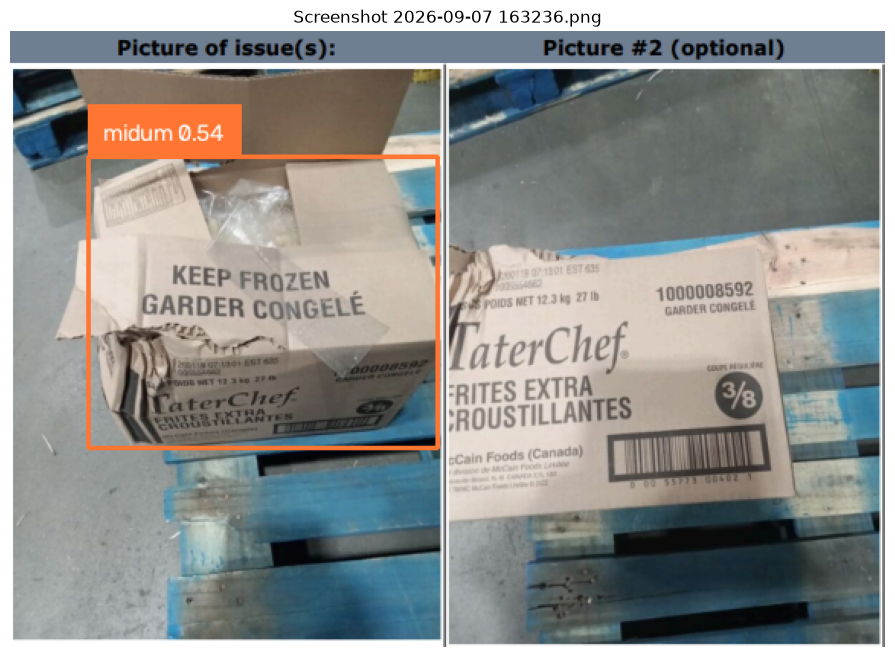

In [29]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import supervision as sv
from rfdetr import RFDETRBase

# --------------------------------------------------
# Paths
# --------------------------------------------------
PROJECT_PATH = Path(
    r"C:\Users\Pushkar Chandra\mccain-internship\week-3\potato-finetuning"
)

OUTPUT_DIR = PROJECT_PATH / "checkpoints" / "rfdetr_run1"
TEST_DIR = PROJECT_PATH / "custom_test_images"

# --------------------------------------------------
# Find the best checkpoint automatically
# --------------------------------------------------
checkpoint_candidates = [
    OUTPUT_DIR / "checkpoint_best_total.pth",
    OUTPUT_DIR / "checkpoint_best_ema.pth",
]

CHECKPOINT = next(
    (p for p in checkpoint_candidates if p.exists()),
    None
)

if CHECKPOINT is None:
    print("Could not find the expected best checkpoint.")
    print("Files in checkpoint directory:")
    for p in OUTPUT_DIR.iterdir():
        print(" -", p.name)
    raise FileNotFoundError("Best checkpoint not found.")

print("Loading checkpoint:")
print(CHECKPOINT)

# --------------------------------------------------
# Load your FINE-TUNED model
# --------------------------------------------------
model = RFDETRBase(
    pretrain_weights=str(CHECKPOINT)
)

print("Fine-tuned model loaded successfully!")

# --------------------------------------------------
# Find test images
# --------------------------------------------------
image_paths = sorted([
    p for p in TEST_DIR.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
])

print(f"\nFound {len(image_paths)} test images:")

for p in image_paths:
    print(" -", p.name)

# --------------------------------------------------
# Run inference
# --------------------------------------------------
for image_path in image_paths:

    image = Image.open(image_path).convert("RGB")

    detections = model.predict(
        image,
        threshold=0.5
    )

    print("\n" + "=" * 60)
    print("IMAGE:", image_path.name)
    print("DETECTIONS:", len(detections))
    print("=" * 60)

    # Print detected objects
    for i in range(len(detections)):

        class_name = detections.data["class_name"][i]
        confidence = detections.confidence[i]
        box = detections.xyxy[i]

        print(
            f"{i+1}. {class_name} "
            f"(confidence={confidence:.3f}) "
            f"box={box.astype(int).tolist()}"
        )

    # --------------------------------------------------
    # Draw bounding boxes
    # --------------------------------------------------
    annotated = sv.BoxAnnotator().annotate(
        scene=image.copy(),
        detections=detections
    )

    labels = [
        f"{class_name} {confidence:.2f}"
        for class_name, confidence in zip(
            detections.data["class_name"],
            detections.confidence
        )
    ]

    annotated = sv.LabelAnnotator().annotate(
        scene=annotated,
        detections=detections,
        labels=labels
    )

    # --------------------------------------------------
    # Display
    # --------------------------------------------------
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated)
    plt.axis("off")
    plt.title(image_path.name)
    plt.show()